In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1 = pd.read_csv("index_1.csv")
df2 = pd.read_csv("index_2.csv")

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         262 non-null    object 
 1   datetime     262 non-null    object 
 2   cash_type    262 non-null    object 
 3   money        262 non-null    float64
 4   coffee_name  262 non-null    object 
dtypes: float64(1), object(4)
memory usage: 10.4+ KB


In [ ]:
df1['cash_type'].value_counts()

,count
cash_type,
card,3547
cash,89


In [ ]:
df1['card'].value_counts()

,count
card,
ANON-0000-0000-0012,129
ANON-0000-0000-0141,108
ANON-0000-0000-1163,77
ANON-0000-0000-0276,69
ANON-0000-0000-0009,67
...,...
ANON-0000-0000-0015,1
ANON-0000-0000-0014,1
ANON-0000-0000-0013,1


In [ ]:
df1['coffee_name'].value_counts()

,count
coffee_name,
Americano with Milk,824
Latte,782
Americano,578
Cappuccino,501
Cortado,292
Hot Chocolate,282
Cocoa,243
Espresso,134


In [ ]:
repeated_counts = df1['card'].value_counts()
bin_counts = [0,1,5,20,float('inf')]
labels = ['one time', 'occasional', 'regular', 'heavy']
customer_counts = repeated_counts.reset_index()
customer_counts.columns = ['card', 'transaction_count']
customer_counts['customer_category'] = pd.cut(customer_counts['transaction_count'], bins=bin_counts, labels=labels)
customer_counts['customer_category'].value_counts()


,count
customer_category,
one time,771
occasional,451
regular,77
heavy,17


# Line plot for monthly wise sales.

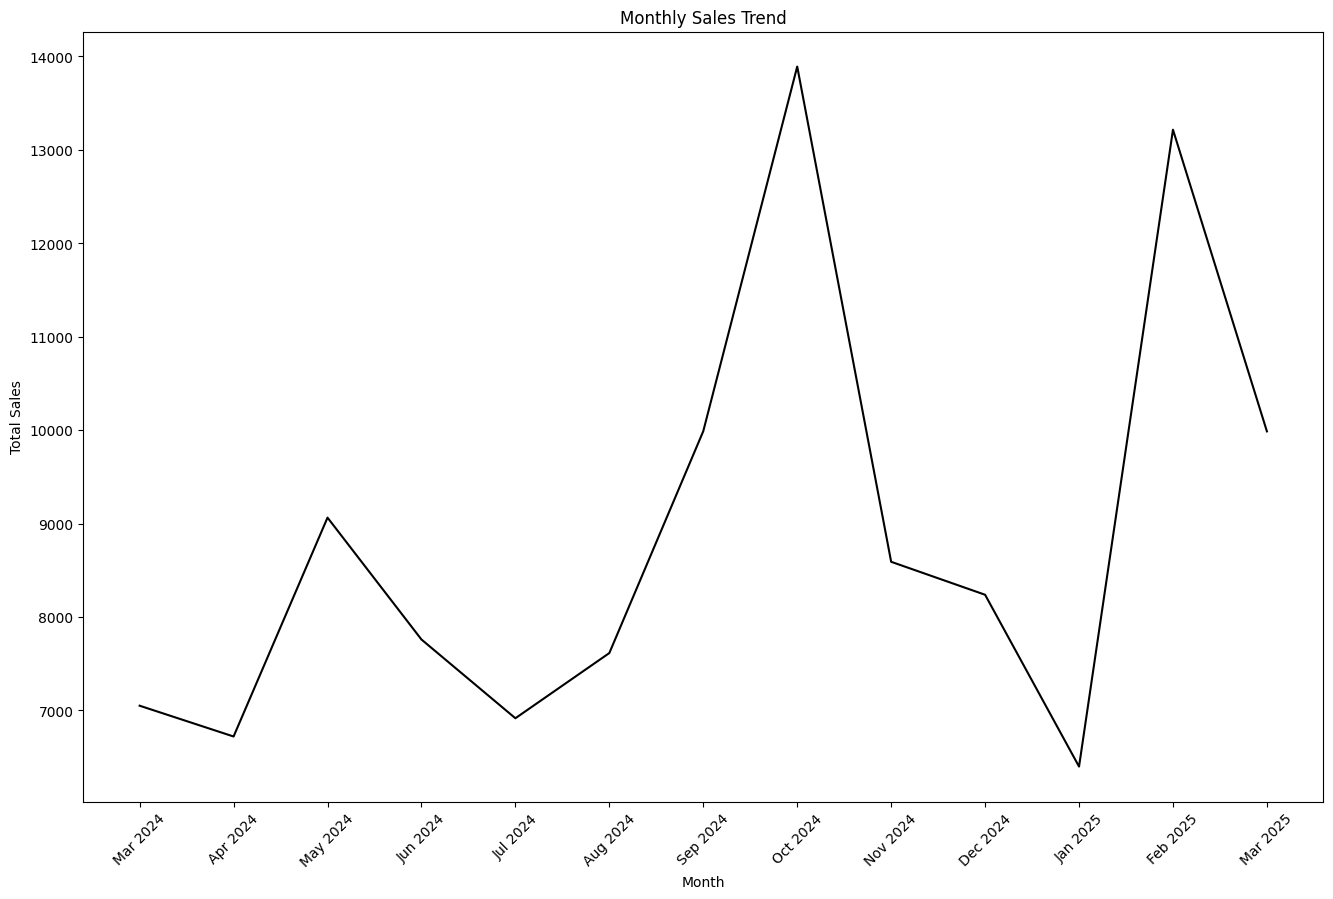

In [ ]:
df1['date'] = pd.to_datetime(df1['date'])
df1['month'] = df1['date'].dt.to_period('M')
sales_by_month = (df1.groupby('month')['money'].sum().reset_index())
sales_by_month['month'] = sales_by_month['month'].dt.to_timestamp()
sales_by_month['month_label'] = sales_by_month['month'].dt.strftime('%b %Y')

plt.figure(figsize=(16, 10))
sns.lineplot(x='month_label', y='money', data=sales_by_month,color='black')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()

In [ ]:
sales_by_month

,month,money,month_label
0,2024-03-01,7050.20,Mar 2024
1,2024-04-01,6720.56,Apr 2024
2,2024-05-01,9063.42,May 2024
3,2024-06-01,7758.76,Jun 2024
4,2024-07-01,6915.94,Jul 2024
5,2024-08-01,7613.84,Aug 2024
6,2024-09-01,9988.64,Sep 2024
7,2024-10-01,13891.16,Oct 2024
8,2024-11-01,8590.54,Nov 2024
9,2024-12-01,8237.74,Dec 2024


In [ ]:
# Ensure datetime
df1['date'] = pd.to_datetime(df1['date'])

# Extract month number
df1['month'] = df1['date'].dt.month

# Assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df1['season'] = df1['month'].apply(get_season)

In [ ]:
season_item = (
    df1
    .groupby(['season', 'coffee_name'])
    .size()
    .reset_index(name='transactions')
)
season_item['pct_within_season'] = (
    season_item
    .groupby('season')['transactions']
    .transform(lambda x: x / x.sum() * 100)
)

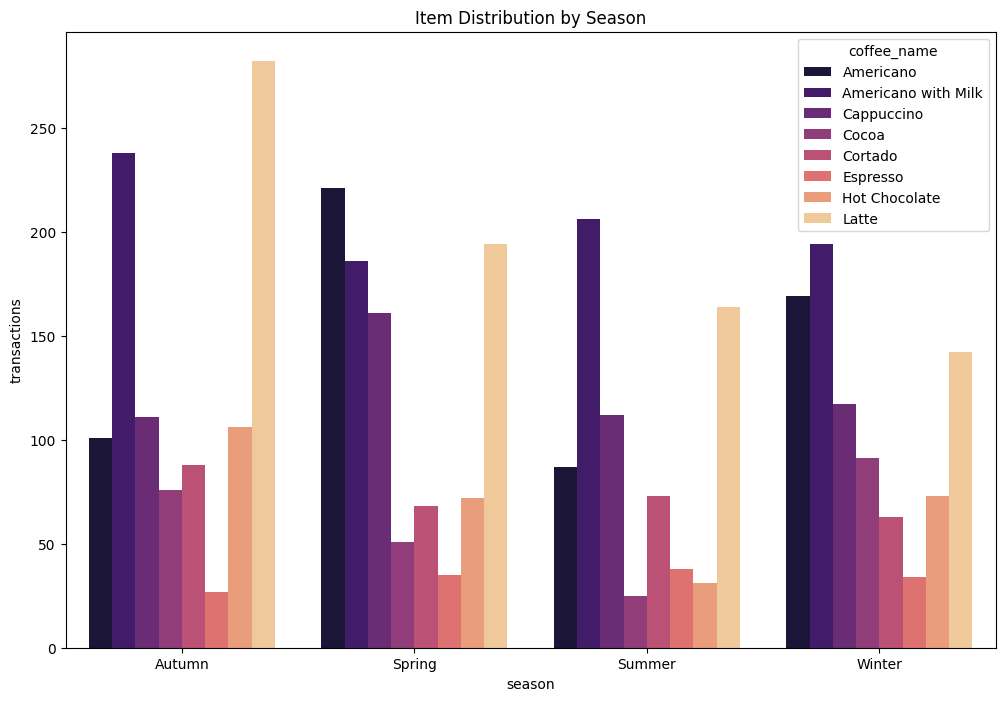

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(data=season_item, x='season', y='transactions', hue='coffee_name',palette='magma')
plt.title('Item Distribution by Season')
plt.show()

# After assigning the customer category to each observation by adding a new column

In [ ]:
df1 = df1.merge(customer_counts[['card', 'customer_category']], on='card', how='left')

In [ ]:
df1

,date,datetime,cash_type,card,money,coffee_name,month,season,customer_category
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,3,Spring,regular
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,3,Spring,occasional
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,3,Spring,occasional
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,3,Spring,heavy
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,3,Spring,regular
...,...,...,...,...,...,...,...,...,...
3631,2025-03-23,2025-03-23 10:34:54.894,card,ANON-0000-0000-1158,35.76,Cappuccino,3,Spring,regular
3632,2025-03-23,2025-03-23 14:43:37.362,card,ANON-0000-0000-1315,35.76,Cocoa,3,Spring,occasional
3633,2025-03-23,2025-03-23 14:44:16.864,card,ANON-0000-0000-1315,35.76,Cocoa,3,Spring,occasional
3634,2025-03-23,2025-03-23 15:47:28.723,card,ANON-0000-0000-1316,25.96,Americano,3,Spring,one time


In [ ]:
df1['customer_category'].value_counts()

,count
customer_category,
occasional,1161
heavy,840
regular,775
one time,771


# Customer Count By category Percentages

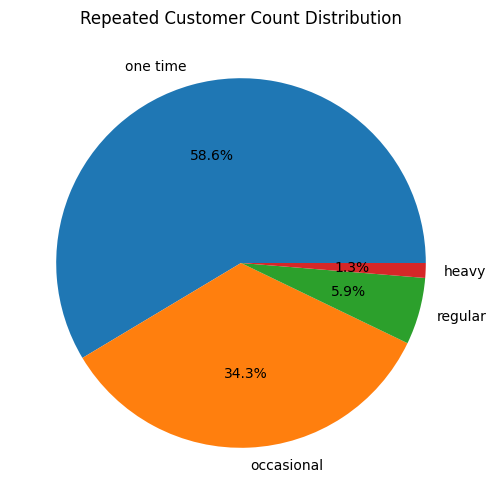

In [ ]:
customer_counts_percentage = (customer_counts['customer_category'].value_counts(normalize = True).sort_index()*100)
plt.figure(figsize=(10,6))
plt.pie(customer_counts_percentage, labels=customer_counts_percentage.index, autopct='%1.1f%%')
plt.title('Repeated Customer Count Distribution')
plt.show()

# Transaction count by category Percentages

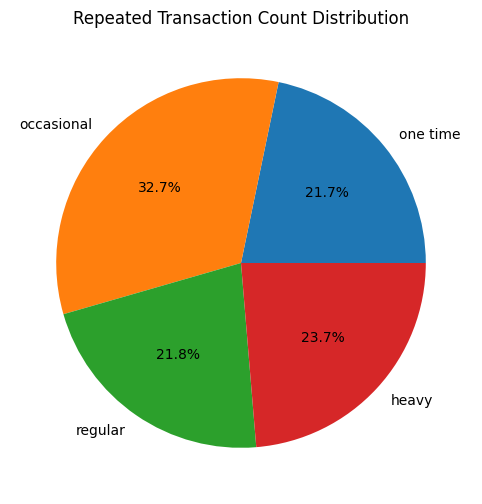

In [ ]:
transaction_counts_percentage = (df1['customer_category'].value_counts(normalize = True).sort_index()*100)
plt.figure(figsize=(10,6))
plt.pie(transaction_counts_percentage, labels=transaction_counts_percentage.index, autopct='%1.1f%%')
plt.title('Repeated Transaction Count Distribution')
plt.show()

# Sales By each Category

In [ ]:
sales_by_category = (df1.groupby("customer_category")["money"].sum().sort_index())
sales_by_category

/tmp/ipython-input-2577734515.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_category = (df1.groupby("customer_category")["money"].sum().sort_index())


,money
customer_category,
one time,24496.70
occasional,37392.54
regular,24829.86
heavy,25526.48


# Sales By each Category on different coffe types aka items

In [ ]:
category_coffee_sales = df1.groupby(['customer_category', 'coffee_name'])['money'].sum().reset_index()

top_coffee_by_category = category_coffee_sales.sort_values(['customer_category', 'coffee_name'],
ascending = [True,False]).groupby('customer_category').head(8)

top_coffee_by_category

/tmp/ipython-input-1581664975.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_coffee_sales = df1.groupby(['customer_category', 'coffee_name'])['money'].sum().reset_index()
/tmp/ipython-input-1581664975.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ascending = [True,False]).groupby('customer_category').head(8)


,customer_category,coffee_name,money
7,one time,Latte,6127.68
6,one time,Hot Chocolate,2127.48
5,one time,Espresso,899.22
4,one time,Cortado,962.48
3,one time,Cocoa,1606.26
2,one time,Cappuccino,4580.70
1,one time,Americano with Milk,5187.90
0,one time,Americano,3004.98
15,occasional,Latte,9804.10
14,occasional,Hot Chocolate,4776.66


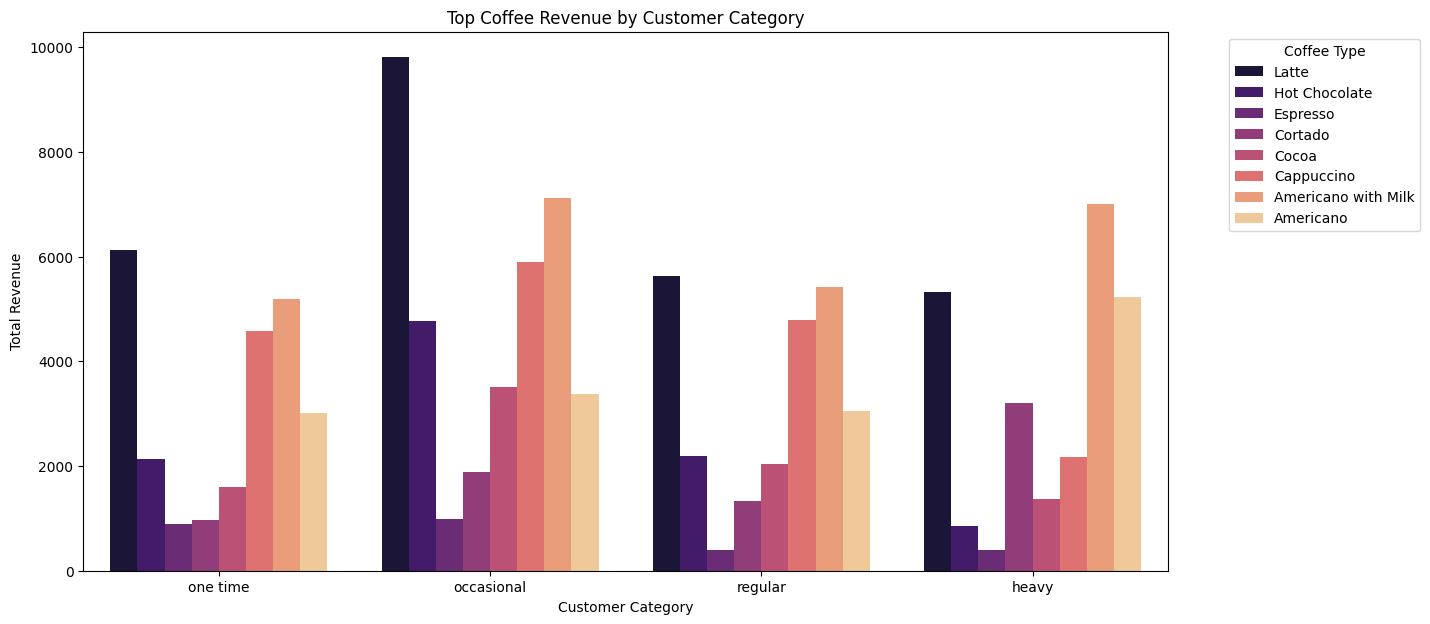

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(data=top_coffee_by_category,x='customer_category',y='money',hue='coffee_name',palette='magma')

plt.title('Top Coffee Revenue by Customer Category')
plt.xlabel('Customer Category')
plt.ylabel('Total Revenue')
plt.legend(title='Coffee Type', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)

plt.show()

Core observation (this is big)

Across all categories, the same drinks keep appearing at the top:
Latte,Americano with Milk,Cappuccino,Americano.

What this means:These are core SKUs.They are universally appealing.They are low-risk, high-demand items.From a business + replenishment point of view:These coffees should never be out of stock.

The Difference between each Category here are
more attention towards Latte and Americano with Milk. Some towards Hot chcolate and Cocoa too so not a big insight.These users are at exploring and experimenting the stock in this new vending machine.

Now about Occasional users Clear Concentration is on Latte, Americano with Milk and Cappuccino and less randomness since they are occasional users. This is the conversion stage.

About Regular customers Latte, Americano with Milk and Cappuchino and the concentration of the sales is also more. This says that people are buying the drinks regularly basically forming habits.

Now about Heavy Users Latte is the one that excells in sales later with Americano with Milk and these people are buying the drinks in their routine.

# Assigning Day to each observation for further analysis

In [ ]:
df1['date'] = pd.to_datetime(df1['date'])
df1['day'] = df1['date'].dt.day_name()
df1['day_num'] = df1['date'].dt.day_of_week
df1

,date,datetime,cash_type,card,money,coffee_name,month,season,customer_category,day,day_num
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,3,Spring,regular,Friday,4
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,3,Spring,occasional,Friday,4
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,3,Spring,occasional,Friday,4
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,3,Spring,heavy,Friday,4
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,3,Spring,regular,Friday,4
...,...,...,...,...,...,...,...,...,...,...,...
3631,2025-03-23,2025-03-23 10:34:54.894,card,ANON-0000-0000-1158,35.76,Cappuccino,3,Spring,regular,Sunday,6
3632,2025-03-23,2025-03-23 14:43:37.362,card,ANON-0000-0000-1315,35.76,Cocoa,3,Spring,occasional,Sunday,6
3633,2025-03-23,2025-03-23 14:44:16.864,card,ANON-0000-0000-1315,35.76,Cocoa,3,Spring,occasional,Sunday,6
3634,2025-03-23,2025-03-23 15:47:28.723,card,ANON-0000-0000-1316,25.96,Americano,3,Spring,one time,Sunday,6


# Total sales in each day of a week entirely

In [ ]:
total_sales_by_day = df1.groupby('day')['money'].sum().reset_index()
total_sales_by_day

,day,money
0,Friday,17257.66
1,Monday,17925.10
2,Saturday,15182.52
3,Sunday,13858.06
4,Thursday,16477.40
5,Tuesday,18637.38
6,Wednesday,16093.46


# How much Week day sell in THIS specific week

In [ ]:
df1['year'] = df1['date'].dt.year
df1['week'] = df1['date'].dt.isocalendar().week
week_day_sales = (df1.groupby(['year','week','day'])['money'].sum().reset_index())
week_day_sales

,year,week,day,money
0,2024,1,Monday,287.54
1,2024,1,Tuesday,508.46
2,2024,9,Friday,396.30
3,2024,9,Saturday,228.10
4,2024,9,Sunday,349.10
...,...,...,...,...
376,2025,12,Saturday,365.42
377,2025,12,Sunday,204.76
378,2025,12,Thursday,597.60
379,2025,12,Tuesday,549.12


# Average accross Weeks.
# This gives on a week which days sells the most or performs better

In [ ]:
avg_sales_by_day = week_day_sales.groupby('day')['money'].mean().reset_index()
avg_sales_by_day

,day,money
0,Friday,308.172500
1,Monday,325.910909
2,Saturday,276.045818
3,Sunday,256.630741
4,Thursday,305.137037
5,Tuesday,338.861455
6,Wednesday,309.489615


From the results we can see that Tuesday and Monday outperforms other days.This suggests routine consumption behavior rather than event-driven or leisure-based demand.

# Best Part making Everything into day order, First day is Monday and last is Sunday.

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_sales_by_day['day'] = pd.Categorical(avg_sales_by_day['day'], categories=day_order, ordered=True)
avg_sales_by_day = avg_sales_by_day.sort_values('day')
avg_sales_by_day

,day,money
1,Monday,325.910909
5,Tuesday,338.861455
6,Wednesday,309.489615
4,Thursday,305.137037
0,Friday,308.172500
2,Saturday,276.045818
3,Sunday,256.630741


From this Monday and Tuesday are the high rist days of stock out.

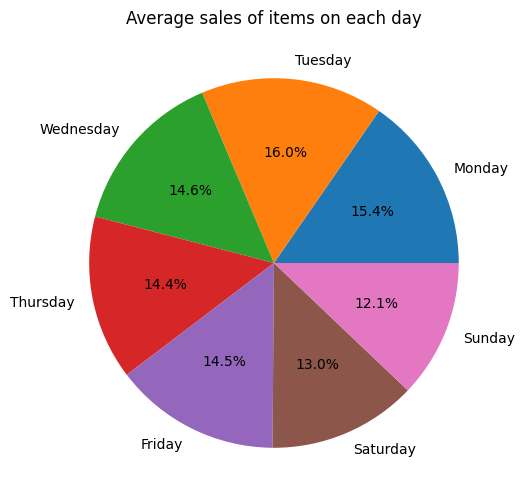

In [ ]:
plt.figure(figsize=(10,6))
plt.pie(avg_sales_by_day['money'], labels=avg_sales_by_day['day'], autopct='%1.1f%%')
plt.title('Average sales of items on each day')
plt.show()

# Categorising transactions into time of the day category that is moninig, noon, evening, night.

In [ ]:
df1['datetime']

,datetime
0,2024-03-01 10:15:50.520
1,2024-03-01 12:19:22.539
2,2024-03-01 12:20:18.089
3,2024-03-01 13:46:33.006
4,2024-03-01 13:48:14.626
...,...
3631,2025-03-23 10:34:54.894
3632,2025-03-23 14:43:37.362
3633,2025-03-23 14:44:16.864
3634,2025-03-23 15:47:28.723


In [ ]:
df1['datetime'] = pd.to_datetime(df1['datetime'])
df1['hour'] = df1['datetime'].dt.hour
def time_of_day_bucket(hour):
    if 6 <= hour < 11:
        return 'Morning'
    elif 11 <= hour < 15:
        return 'Afternoon'
    elif 15 <= hour < 19:
        return 'Evening'
    else:
        return 'Night'

df1['time_of_day'] = df1['hour'].apply(time_of_day_bucket)
df1

,date,datetime,cash_type,card,money,coffee_name,month,season,customer_category,day,day_num,year,week,hour,time_of_day
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,3,Spring,regular,Friday,4,2024,9,10,Morning
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,3,Spring,occasional,Friday,4,2024,9,12,Afternoon
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,3,Spring,occasional,Friday,4,2024,9,12,Afternoon
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,3,Spring,heavy,Friday,4,2024,9,13,Afternoon
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,3,Spring,regular,Friday,4,2024,9,13,Afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3631,2025-03-23,2025-03-23 10:34:54.894,card,ANON-0000-0000-1158,35.76,Cappuccino,3,Spring,regular,Sunday,6,2025,12,10,Morning
3632,2025-03-23,2025-03-23 14:43:37.362,card,ANON-0000-0000-1315,35.76,Cocoa,3,Spring,occasional,Sunday,6,2025,12,14,Afternoon
3633,2025-03-23,2025-03-23 14:44:16.864,card,ANON-0000-0000-1315,35.76,Cocoa,3,Spring,occasional,Sunday,6,2025,12,14,Afternoon
3634,2025-03-23,2025-03-23 15:47:28.723,card,ANON-0000-0000-1316,25.96,Americano,3,Spring,one time,Sunday,6,2025,12,15,Evening


# Line graph of distribution of sales and transactions wrt month number here

<Axes: xlabel='week', ylabel='money'>

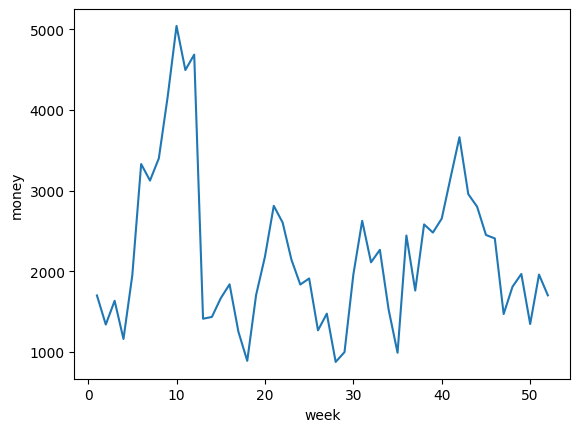

In [ ]:
sales_by_week = (df1.groupby('week')['money'].sum().reset_index())
sns.lineplot(x='week',y='money',data=sales_by_week)

<Axes: xlabel='week', ylabel='transactions'>

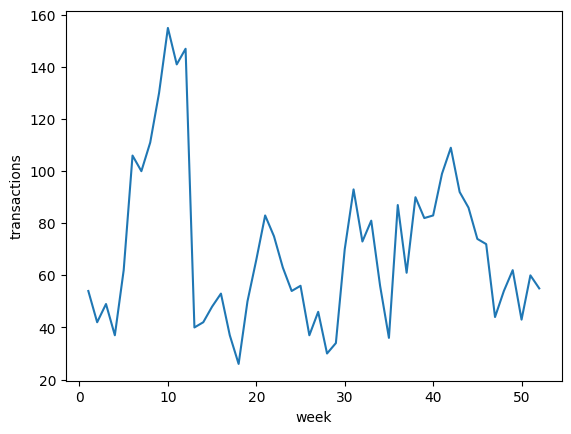

In [ ]:
txn_count_by_week = (df1.groupby('week').size().reset_index(name='transactions'))
sns.lineplot(x='week',y='transactions',data=txn_count_by_week)

# Next big observation Transaction Count by time of day X Customer Category

In [ ]:
txn_count_by_customer_category = (df1.groupby(['time_of_day','customer_category']).size().reset_index(name='transactions'))
txn_count_by_customer_category

/tmp/ipython-input-3502239344.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  txn_count_by_customer_category = (df1.groupby(['time_of_day','customer_category']).size().reset_index(name='transactions'))


,time_of_day,customer_category,transactions
0,Afternoon,one time,240
1,Afternoon,occasional,322
2,Afternoon,regular,193
3,Afternoon,heavy,219
4,Evening,one time,229
5,Evening,occasional,310
6,Evening,regular,223
7,Evening,heavy,207
8,Morning,one time,162
9,Morning,occasional,247


In [ ]:
txn_count_by_customer_category['pcnt_within_category'] = (txn_count_by_customer_category.groupby('customer_category')['transactions'].transform(lambda x: x / x.sum() * 100))
txn_count_by_customer_category.head()

/tmp/ipython-input-2524252272.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  txn_count_by_customer_category['pcnt_within_category'] = (txn_count_by_customer_category.groupby('customer_category')['transactions'].transform(lambda x: x / x.sum() * 100))


,time_of_day,customer_category,transactions,pcnt_within_category
0,Afternoon,one time,240,31.128405
1,Afternoon,occasional,322,27.734711
2,Afternoon,regular,193,24.903226
3,Afternoon,heavy,219,26.071429
4,Evening,one time,229,29.701686


In [ ]:
txn_pivot = txn_count_by_customer_category.pivot(index='time_of_day',columns='customer_category',values='pcnt_within_category')
txn_pivot

customer_category,one time,occasional,regular,heavy
time_of_day,,,,
Afternoon,31.128405,27.734711,24.903226,26.071429
Evening,29.701686,26.701120,28.774194,24.642857
Morning,21.011673,21.274763,27.483871,32.857143
Night,18.158236,24.289406,18.838710,16.428571


# Item distribution by time of day

In [ ]:
item_time_dist = (df1.groupby(['time_of_day','coffee_name']).size().reset_index(name='transactions'))
item_time_dist['pcnt_within_category'] = (item_time_dist.groupby('time_of_day')['transactions'].transform(lambda x: x / x.sum() * 100))
item_time_dist_pivot = item_time_dist.pivot(index = 'time_of_day', columns='coffee_name', values='pcnt_within_category')
item_time_dist_pivot

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
time_of_day,,,,,,,,
Afternoon,22.044088,22.444890,12.725451,5.811623,9.719439,4.709419,4.909820,17.635271
Evening,15.826613,18.245968,15.221774,7.258065,5.141129,4.435484,10.383065,23.487903
Morning,16.396980,29.018339,10.355987,4.638619,11.866235,3.344121,3.559871,20.819849
Night,6.815021,20.862309,17.663421,9.735744,4.728790,1.668985,13.490960,25.034771


Item-level demand varies significantly by time of day. Core beverages such as Latte and Americano with Milk dominate across all periods, while secondary items exhibit time-specific importance. This segmentation enables prioritization of stock levels during replenishment without disrupting peak customer interactions.

# Refill Frequency

In [ ]:
df1['week_of_month'] = ((df1['date'].dt.day - 1) // 7) + 1

This creates:

1 → days 1–7

2 → days 8–14

3 → days 15–21

4 → days 22–28

5 → remaining days (if any)

In [ ]:
wom_txn = (df1.groupby('week_of_month').size().reset_index(name='transactions'))
wom_txn['pcnt_txn'] = wom_txn['transactions'] / wom_txn['transactions'].sum() * 100
wom_txn

,week_of_month,transactions,pcnt_txn
0,1,845,23.239824
1,2,859,23.624862
2,3,904,24.862486
3,4,751,20.654565
4,5,277,7.618262


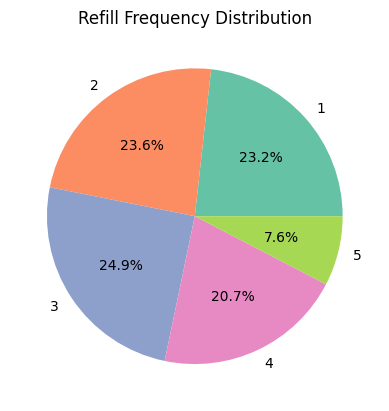

In [ ]:
plt.pie(x='pcnt_txn',labels='week_of_month',data=wom_txn,autopct='%1.1f%%',colors=sns.color_palette('Set2'))
plt.title('Refill Frequency Distribution')
plt.show()

# Revenue Analysis

# Customer Category and Time of day

In [ ]:
sales_by_time_of_day = (df1.groupby(['time_of_day','customer_category'])['money'].sum().reset_index())
sales_by_time_of_day

/tmp/ipython-input-241016104.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_time_of_day = (df1.groupby(['time_of_day','customer_category'])['money'].sum().reset_index())


,time_of_day,customer_category,money
0,Afternoon,one time,7474.02
1,Afternoon,occasional,10247.58
2,Afternoon,regular,5877.58
3,Afternoon,heavy,6476.10
4,Evening,one time,7292.34
5,Evening,occasional,10154.60
6,Evening,regular,7374.72
7,Evening,heavy,6508.56
8,Morning,one time,5119.86
9,Morning,occasional,7692.98


In [ ]:
sales_by_time_of_day['pcnt_within_category'] = (sales_by_time_of_day.groupby('customer_category')['money'].transform(lambda x: x / x.sum() * 100))
sales_pivot = sales_by_time_of_day.pivot(index='time_of_day',columns='customer_category',values='pcnt_within_category')
sales_pivot

/tmp/ipython-input-4126035767.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_time_of_day['pcnt_within_category'] = (sales_by_time_of_day.groupby('customer_category')['money'].transform(lambda x: x / x.sum() * 100))


customer_category,one time,occasional,regular,heavy
time_of_day,,,,
Afternoon,30.510314,27.405413,23.671418,25.370125
Evening,29.768663,27.156754,29.701013,25.497288
Morning,20.900203,20.573569,26.780739,31.393439
Night,18.820821,24.864264,19.846830,17.739148


“The analysis indicates that vending machine availability is highly time-sensitive. A full-day outage can result in significant revenue loss, particularly due to missed high-value consumption windows. To minimize impact, repairs should be completed on the same day, ideally during nighttime hours when transaction volume is lowest. In cases of unavoidable downtime, redirecting customers to a nearby alternative machine can partially mitigate losses, provided the replacement is within minimal walking distance.